In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [24]:
selectedModel="gemini-2.5-flash"

In [22]:
import os
load_dotenv()
API_KEY = os.getenv("GEMINI_API_KEY")

In [ ]:

os.environ["GEMINI_API_KEY"] = API_KEY

In [25]:
llm = ChatGoogleGenerativeAI(
    model=selectedModel,
    temperature=0.7
)

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [ ]:
# llm = ChatOpenAI()

In [18]:
def chat_node(state: ChatState):
    # take user query from state
    user_query = state["messages"]

    # ask llm to respond to user query
    response = llm.invoke(user_query)

    # return response and update state with user query and llm response
    return {'messages': [response]}

In [19]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node("chat_node", chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

# run graph
workflow = graph.compile(checkpointer=checkpointer)

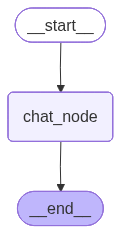

In [20]:
workflow

In [26]:
thread_id = '1'

while True:
    user_message = input("Type your message: ")
    print(f"User: {user_message}")

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Exiting chat. Goodbye!")
        break
    
    config = {
        'configurable': {
            'thread_id': thread_id
        }
    }

    llm_response = workflow.invoke({
            'messages': [HumanMessage(content=user_message)]
        },
        config=config
    )

    print(f"AI: {llm_response['messages'][-1].content}")






User: hi my name is john
AI: Hi John! It's nice to meet you.

How can I help you today?
User: what is my name?
AI: Based on what you just told me, your name is **John**.
User: what is 10 + 2
AI: 10 + 2 = **12**
User: now add 5 more to it
AI: Okay! So, 12 + 5 = **17**.
User: what is the total result for me? and what is my name
AI: The total result for you is **17**.

And your name is **John**.
User: exit
Exiting chat. Goodbye!


In [23]:
import google.generativeai as genai

genai.configure(api_key=API_KEY)

models = genai.list_models()

for m in models:
    print(m.name)

c:\Users\rajiv\Documents\workspace\Langgraph-project\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\rajiv\AppData\Local\Temp\ipykernel_48668\3588737407.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev